In [1]:
import torch
import torch.nn as nn

class MyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Define layers here — PyTorch registers their weights automatically
        self.layer1 = nn.Linear(in_features=8, out_features=16)
        self.layer2 = nn.Linear(in_features=16, out_features=1)

    def forward(self, x):
        # Define the computation — how data flows through layers
        x = self.layer1(x)
        x = self.layer2(x)
        return x

model = MyNetwork()
print(model)
print("Total params:", sum(p.numel() for p in model.parameters()))

MyNetwork(
  (layer1): Linear(in_features=8, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=1, bias=True)
)
Total params: 161


Main Insight
nn.Linear already contains:


weights


biases


gradient tracking


random initialization


You do NOT create these manually.
PyTorch handles it.

---------

Quick Summary
nn.Module:


organizes neural networks


tracks parameters automatically


supports save/load + GPU + train/eval


__init__():


define layers


forward():


define data flow


nn.Linear(in,out):


fully connected layer


computes weighted sum + bias


Main concept:
Neural networks are built by composing layers inside nn.Module while PyTorch automatically manages millions of learnable parameters for you

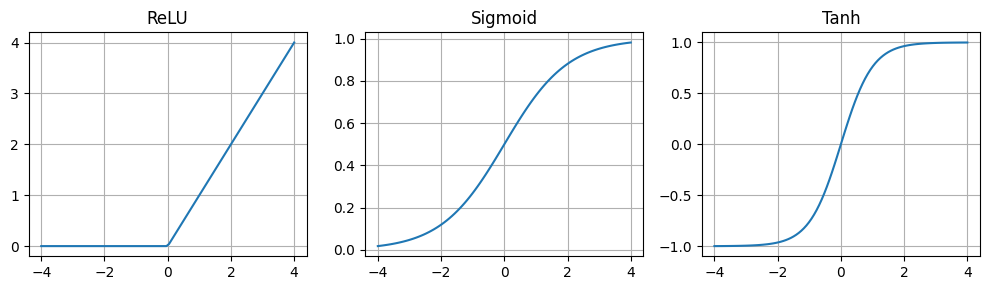

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

x = torch.linspace(-4, 4, 100)

plt.figure(figsize=(10, 3))
plt.subplot(1,3,1); plt.plot(x, F.relu(x))
plt.title('ReLU'); plt.grid(True)
plt.subplot(1,3,2); plt.plot(x, torch.sigmoid(x))
plt.title('Sigmoid'); plt.grid(True)
plt.subplot(1,3,3); plt.plot(x, torch.tanh(x))
plt.title('Tanh'); plt.grid(True)
plt.tight_layout(); plt.show()


In [3]:
class BetterNetwork(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))   # Linear → ReLU
        x = F.relu(self.fc2(x))   # Linear → ReLU
        x = torch.sigmoid(self.fc3(x))  # Binary output → Sigmoid
        return x

model = BetterNetwork(input_dim=9)
print(model)
print("Params:", sum(p.numel() for p in model.parameters()))

BetterNetwork(
  (fc1): Linear(in_features=9, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)
Params: 2753


MOST Important Concept
Neural networks become powerful because:
Linear layers learn combinations



Activation functions create non-linearity
Without activations:
Deep network ≈ linear regression
With activations:
Deep network learns complex patterns

Quick Summary
Activation functions:


introduce non-linearity


allow complex learning


Common activations:
ActivationUseReLUhidden layersSigmoidbinary outputSoftmaxmulti-classNoneregression

Your network:
9→64(ReLU)→32(ReLU)→1(Sigmoid)

Main concept:
Depth alone does not make neural networks powerful — non-linear activation functions do.

In [5]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the clean dataset from Week 1
df = pd.read_csv('clean_titanic.csv')
X = df.drop('Survived', axis=1).values.astype('float32')
y = df['Survived'].values.astype('float32')

# Scale features — important for neural nets
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to tensors
X_train = torch.tensor(X_train)
X_val   = torch.tensor(X_val)
y_train = torch.tensor(y_train).unsqueeze(1)  # shape [N,1]
y_val   = torch.tensor(y_val).unsqueeze(1)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: torch.Size([712, 10])
y_train: torch.Size([712, 1])


In [6]:
input_dim = X_train.shape[1]
model     = BetterNetwork(input_dim=input_dim)

# BCELoss = binary cross-entropy — correct loss for binary classification
criterion = nn.BCELoss()

# Adam optimiser — much better than plain SGD for most problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
train_losses, val_losses = [], []

for epoch in range(100):

    # --- TRAINING ---
    model.train()                          # tell model it's training time
    optimizer.zero_grad()                  # clear old gradients

    y_pred = model(X_train)               # forward pass
    loss   = criterion(y_pred, y_train)   # compute loss

    loss.backward()                        # backward pass
    optimizer.step()                       # update weights

    # --- VALIDATION ---
    model.eval()                           # tell model it's eval time
    with torch.no_grad():                  # no gradients needed for eval
        y_val_pred = model(X_val)
        val_loss   = criterion(y_val_pred, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train loss: {loss.item():.4f} | val loss: {val_loss.item():.4f}")

Epoch   0 | train loss: 0.7003 | val loss: 0.6961
Epoch  10 | train loss: 0.6467 | val loss: 0.6489
Epoch  20 | train loss: 0.5855 | val loss: 0.5947
Epoch  30 | train loss: 0.5198 | val loss: 0.5397
Epoch  40 | train loss: 0.4632 | val loss: 0.4953
Epoch  50 | train loss: 0.4284 | val loss: 0.4712
Epoch  60 | train loss: 0.4124 | val loss: 0.4621
Epoch  70 | train loss: 0.4037 | val loss: 0.4566
Epoch  80 | train loss: 0.3967 | val loss: 0.4512
Epoch  90 | train loss: 0.3910 | val loss: 0.4474


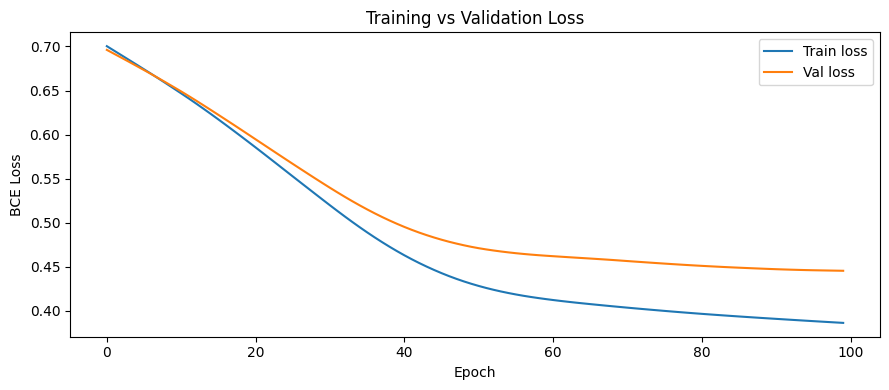

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.title('Training vs Validation Loss')
plt.legend(); plt.tight_layout(); plt.show()

Four Must-Know Lines
1. optimizer.zero_grad()

Purpose:

Clear old gradients

Because gradients accumulate.

2. loss.backward()

Purpose:

Compute gradients

Autograd calculates weight corrections.

3. optimizer.step()

Purpose:

Update model weights

Learning actually happens here.

4. torch.no_grad()

Purpose:

Disable gradients during evaluation

Because validation only measures.

Big Mental Model

Whole process:

Train mode
→ clear gradients
→ predict
→ compute loss
→ backward
→ update
→ eval mode
→ validate
→ repeat

This is:

The complete neural-network training loop

----------

Quick Summary

Pipeline stages:

# scale data
# tensor conversion
# define model
# define loss
# define optimizer
# training loop
# validation loop
# plot losses

Core learning lines:

Line	Meaning
zero_grad	clear old gradients
backward	compute gradients
step	update weights
no_grad	eval without learning

Main concept:

Neural-network training is repeated prediction, error measurement, gradient computation, and weight updates while validation checks whether learning generalizes or overfits.

In [9]:
from sklearn.metrics import accuracy_score, classification_report

model.eval()
with torch.no_grad():
    probs = model(X_val)
    preds = (probs >= 0.5).float()

acc = accuracy_score(y_val.numpy(), preds.numpy())
print(f"Neural network val accuracy: {acc:.4f}")
print(classification_report(y_val.numpy(), preds.numpy()))

Neural network val accuracy: 0.7877
              precision    recall  f1-score   support

         0.0       0.80      0.87      0.83       110
         1.0       0.76      0.65      0.70        69

    accuracy                           0.79       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179



In [10]:
print("Week 1 Tuned Random Forest: ~83.8%")
print(f"Week 2 Neural Network:       {acc*100:.1f}%")
print()
print("Which is better? Why might that be?")

Week 1 Tuned Random Forest: ~83.8%
Week 2 Neural Network:       78.8%

Which is better? Why might that be?


In [11]:
# Try these one at a time and note the effect on val accuracy

# More neurons?
# self.fc1 = nn.Linear(input_dim, 128)

# More layers?
# self.fc4 = nn.Linear(32, 16)  # add a 4th layer

# Different learning rate?
# optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# More epochs?
# for epoch in range(200):

Mental Model

Training:

Can model learn?

Evaluation:

Did model generalize?

Comparison:

Was this model the right choice?

Experimentation:

How do architecture decisions affect learning?

Quick Summary
Evaluation flow:


eval() → evaluation mode


no_grad() → no learning


probabilities from sigmoid


threshold at 0.5


compute accuracy + report


Important lesson:


Neural networks are not always best


Random Forest may outperform on small tabular data


Model choice depends on dataset


Experimentation rule:
Change one thing at a time
Main concept:
Good ML engineers do not assume bigger models are better — they compare, evaluate honestly, and build intuition through controlled experiments.